In [ ]:
from google.colab import files
files.upload()  # Upload kaggle.json here


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ayushus","key":"763b97d20f825f51f5057eeac16df17f"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 99% 2.27G/2.29G [00:13<00:00, 247MB/s]
100% 2.29G/2.29G [00:13<00:00, 181MB/s]


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
train_dir = 'chest_xray/train'
test_dir = 'chest_xray/test'


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2  # 20% for validation
)

test_datagen = ImageDataGenerator(rescale=1./255)


In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
#load resnet50 base and add custom layers
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze all layers initially

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#Compile and Train (Phase 1 – Feature Extraction)
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(patience=4, restore_best_weights=True)

history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 123s 827ms/step - accuracy: 0.7025 - loss: 0.6180 - val_accuracy: 0.7430 - val_loss: 0.5329
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 733ms/step - accuracy: 0.7451 - loss: 0.5376 - val_accuracy: 0.7459 - val_loss: 0.4914
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 732ms/step - accuracy: 0.7567 - loss: 0.4794 - val_accuracy: 0.7900 - val_loss: 0.4512
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 733ms/step - accuracy: 0.7808 - loss: 0.4385 - val_accuracy: 0.7872 - val_loss: 0.4520
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 94s 717ms/step - accuracy: 0.7809 - loss: 0.4329 - val_accuracy: 0.8025 - val_loss: 0.4029
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 94s 721ms/step - accuracy: 0.8027 - loss: 0.4042 - val_accuracy: 0.7718 - val_loss: 0.4739
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 99s 753ms/step - accuracy: 0.8099 - loss: 0.3992 - val_accuracy: 0.8140 - val_loss: 0.3886
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 95s 727ms/step - accuracy: 0.8087 - loss: 

In [ ]:
#prediction on validation set
# Get predicted probabilities from the model
val_preds = model.predict(val_generator)

# Convert probabilities to binary class labels (0 or 1)
val_preds_class = (val_preds > 0.5).astype(int)


33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 721ms/step


In [ ]:
#classification report
from sklearn.metrics import classification_report

# Get ground truth labels from the generator
val_labels = val_generator.classes

# Get class names from the generator (e.g., ['NORMAL', 'PNEUMONIA'])
class_names = list(val_generator.class_indices.keys())

print("Classification Report (Validation Set):\n")
print(classification_report(val_labels, val_preds_class, target_names=class_names))


Classification Report (Validation Set):

              precision    recall  f1-score   support

      NORMAL       0.27      0.25      0.26       268
   PNEUMONIA       0.75      0.76      0.76       775

    accuracy                           0.63      1043
   macro avg       0.51      0.51      0.51      1043
weighted avg       0.63      0.63      0.63      1043



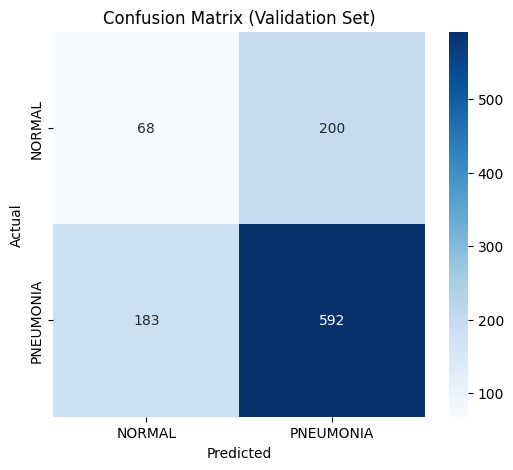

In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(val_labels, val_preds_class)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


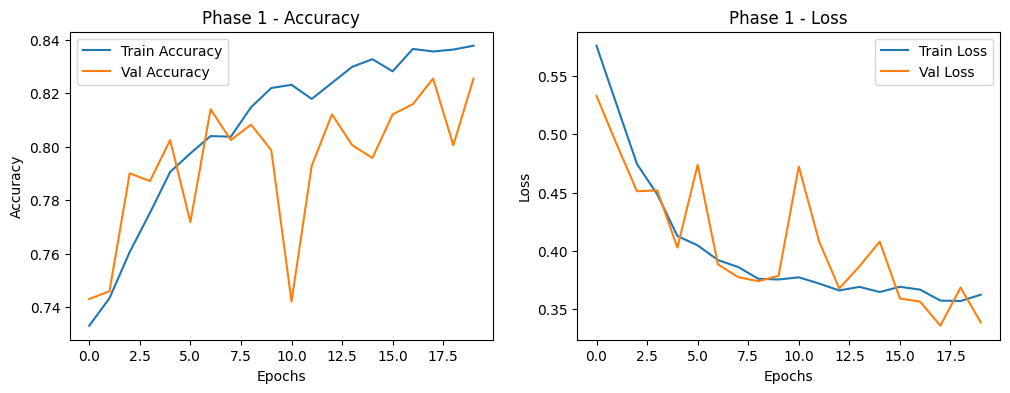

In [ ]:
def plot_training(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Train Accuracy')
    plt.plot(val_acc, label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training(history1, "Phase 1")


In [ ]:
#phase-2 fine tunning
# Unfreeze the top layers of the ResNet50 base model
base_model.trainable = True

# Optionally: freeze the bottom N layers (e.g., first 100 layers) if needed
for layer in base_model.layers[:100]:
    layer.trainable = False


In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile with a much lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # smaller LR to fine-tune safely
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

checkpoint = ModelCheckpoint("resnet50_finetuned.h5", monitor='val_loss', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.2, min_lr=1e-7, verbose=1)

# Fine-tuning
history_fine = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop, reduce_lr]
)


Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.7580 - loss: 0.5296
Epoch 1: val_loss improved from inf to 1.25096, saving model to resnet50_finetuned.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 149s 896ms/step - accuracy: 0.7586 - loss: 0.5283 - val_accuracy: 0.2570 - val_loss: 1.2510 - learning_rate: 1.0000e-05
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.8931 - loss: 0.2454
Epoch 2: val_loss improved from 1.25096 to 0.57258, saving model to resnet50_finetuned.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 806ms/step - accuracy: 0.8932 - loss: 0.2454 - val_accuracy: 0.7430 - val_loss: 0.5726 - learning_rate: 1.0000e-05
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.9109 - loss: 0.2048
Epoch 3: val_loss improved from 0.57258 to 0.47847, saving model to resnet50_finetuned.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 102s 780ms/step - accuracy: 0.9109 - loss: 0.2047 - val_accuracy: 0.8245 - val_loss: 0.4785 - learning_rate: 1.0000e-05
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.9156 - loss: 0.2055
Epoch 4: val_loss improved from 0.47847 to 0.37816, saving model to resnet50_finetuned.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 816ms/step - accuracy: 0.9157 - loss: 0.2053 - val_accuracy: 0.8408 - val_loss: 0.3782 - learning_rate: 1.0000e-05
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.9267 - loss: 0.2044
Epoch 5: val_loss improved from 0.37816 to 0.14394, saving model to resnet50_finetuned.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 815ms/step - accuracy: 0.9268 - loss: 0.2042 - val_accuracy: 0.9386 - val_loss: 0.1439 - learning_rate: 1.0000e-05
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - accuracy: 0.9380 - loss: 0.1718
Epoch 6: val_loss did not improve from 0.14394
131/131 ━━━━━━━━━━━━━━━━━━━━ 99s 759ms/step - accuracy: 0.9380 - loss: 0.1717 - val_accuracy: 0.9386 - val_loss: 0.1676 - learning_rate: 1.0000e-05
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.9471 - loss: 0.1416
Epoch 7: val_loss did not improve from 0.14394

Epoch 7: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
131/131 ━━━━━━━━━━━━━━━━━━━━ 102s 778ms/step - accuracy: 0.9471 - loss: 0.1416 - val_accuracy: 0.5666 - val_loss: 1.4238 - learning_rate: 1.0000e-05
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.9493 - loss: 0.1439
Epoch 8: val_loss did not improve from 0.14394
131/131 ━━━━━━━━━━━━━━━━━━━━ 99s 758ms/step - accuracy: 0.9493 - loss: 

131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 814ms/step - accuracy: 0.9555 - loss: 0.1230 - val_accuracy: 0.9569 - val_loss: 0.1030 - learning_rate: 2.0000e-06
Epoch 10/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.9522 - loss: 0.1112
Epoch 10: val_loss did not improve from 0.10299
131/131 ━━━━━━━━━━━━━━━━━━━━ 102s 781ms/step - accuracy: 0.9522 - loss: 0.1112 - val_accuracy: 0.9214 - val_loss: 0.2043 - learning_rate: 2.0000e-06
Epoch 11/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.9565 - loss: 0.1188
Epoch 11: val_loss did not improve from 0.10299

Epoch 11: ReduceLROnPlateau reducing learning rate to 3.999999989900971e-07.
131/131 ━━━━━━━━━━━━━━━━━━━━ 101s 774ms/step - accuracy: 0.9565 - loss: 0.1188 - val_accuracy: 0.9588 - val_loss: 0.1122 - learning_rate: 2.0000e-06
Epoch 12/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.9566 - loss: 0.1094
Epoch 12: val_loss did not improve from 0.10299
131/131 ━━━━━━━━━━━━━━━━━━━━ 102s 775ms/step - accuracy: 0.9566 

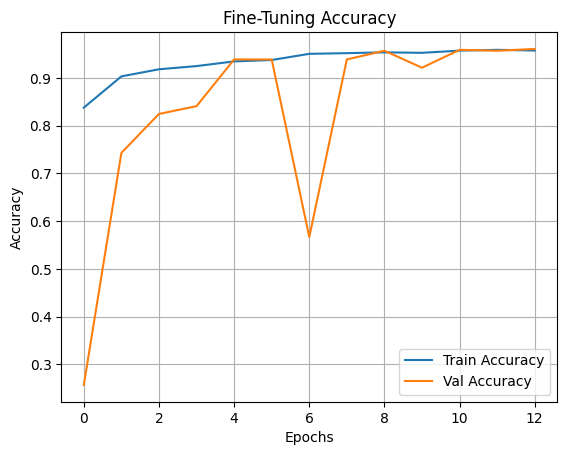

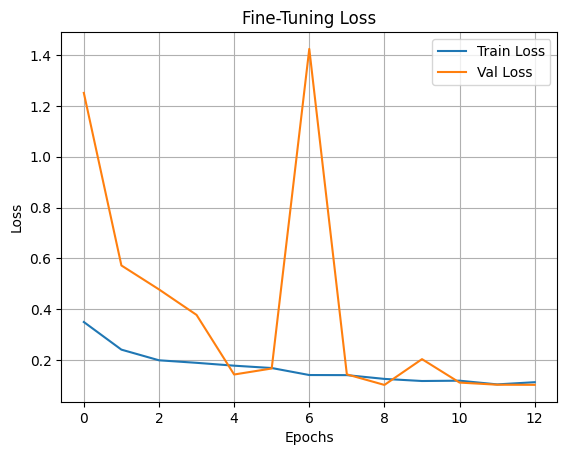

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Val Accuracy')
plt.title('Fine-Tuning Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
print("\n")
# Plot loss
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Val Loss')
plt.title('Fine-Tuning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from tensorflow.keras.models import load_model

# Load the best saved model from fine-tuning phase
model = load_model("resnet50_finetuned.h5")


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define test directory
test_dir = "/content/chest_xray/test"

# Only rescale, no augmentation for test data
test_datagen = ImageDataGenerator(rescale=1./255)

# Flow test images in batches
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # Do not shuffle for evaluation
)


Found 624 images belonging to 2 classes.


In [ ]:
#predict on test set
import numpy as np

# Predict probabilities
y_pred_probs = model.predict(test_generator)
# Convert to binary predictions (0 or 1)
y_pred = np.where(y_pred_probs > 0.5, 1, 0)

# True labels
y_true = test_generator.classes


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 479ms/step


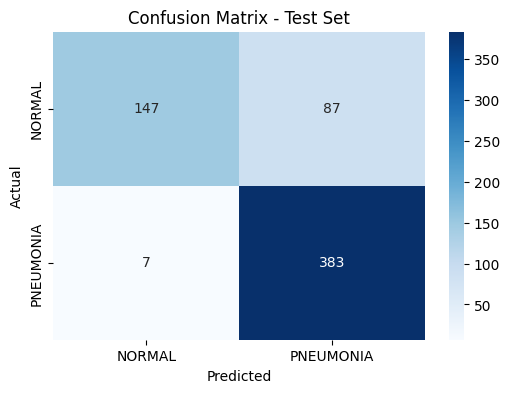

Classification Report (Test Set):

              precision    recall  f1-score   support

      NORMAL       0.95      0.63      0.76       234
   PNEUMONIA       0.81      0.98      0.89       390

    accuracy                           0.85       624
   macro avg       0.88      0.81      0.82       624
weighted avg       0.87      0.85      0.84       624



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_names = list(test_generator.class_indices.keys())

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report (Test Set):\n")
print(report)


In [ ]:
model = tf.keras.models.load_model("resnet50_finetuned.h5")
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,115 (90.98 MB)

 Trainable params: 19,715,329 (75.21 MB)

 Non-trainable params: 4,134,784 (15.77 MB)

 Optimizer params: 2 (12.00 B)

In [ ]:
from google.colab import files
files.download("resnet50_finetuned.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>